## SNN network implementation

In [176]:
%pip install snntorch

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import snntorch as snn
from snntorch import surrogate
from snntorch import functional as SF

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import os


In [2]:
transform = transforms.Compose([
    transforms.Resize((16, 16)),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1))  # flatten 16x16 → 256
])


batch_size = 64
train_ds = datasets.MNIST(root="data", train=True, transform=transform, download=True)
test_ds  = datasets.MNIST(root="data", train=False, transform=transform, download=True)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False)


### SNN Architecture (LIF Model)

Here we consider only 1 hidden layer.
I don't  pass the threshold in any snn.Leaky(). So it uses the default **threshold = 1.0**

In [3]:
class SNN_FPGAModel(nn.Module):
    def __init__(self, hidden=32, beta=0.9):
        super().__init__()

        # First fully connected layer and LIF neuron (input to hidden)
        self.fc1 = nn.Linear(256, hidden)
        self.lif1 = snn.Leaky(beta=beta, spike_grad=surrogate.fast_sigmoid())
        
        # Single hidden layer (hidden to output)
        self.fc2 = nn.Linear(hidden, 10)
        self.lif_out = snn.Leaky(beta=beta, spike_grad=surrogate.fast_sigmoid())

    def forward(self, x, num_steps=20):
        # RESET STATES FOR EACH FORWARD PASS
        mem1 = self.lif1.init_leaky()
        mem_out = self.lif_out.init_leaky()

        spk_rec = []

        for t in range(num_steps):
            cur1 = self.fc1(x)
            spk1, mem1 = self.lif1(cur1, mem1)

            cur2 = self.fc2(spk1)

            spk_out, mem_out = self.lif_out(cur2, mem_out)
            spk_rec.append(spk_out)

        return torch.stack(spk_rec)
    

    # Debug forward pass with full internal state capture
    def forward_debug(self, x, num_steps=20):
        # Reset states
        mem1 = self.lif1.init_leaky()
        mem_out = self.lif_out.init_leaky()

        # Storage dictionaries
        debug = {
            "cur1": [], "mem1": [], "spk1": [],
        }

        debug.update({
            "cur_out": [], "mem_out": [], "spk_out": [],
        })

        # Time loop
        for t in range(num_steps):
            # ------ Input Layer to Hidden Layer ------
            cur1 = self.fc1(x)
            spk1, mem1 = self.lif1(cur1, mem1)

            debug["cur1"].append(cur1.detach().cpu().numpy())
            debug["mem1"].append(mem1.detach().cpu().numpy())
            debug["spk1"].append(spk1.detach().cpu().numpy())

            # ------ Hidden Layer to Output Layer ------
            cur2 = self.fc2(spk1)
            spk_out, mem_out = self.lif_out(cur2, mem_out)

            debug["cur_out"].append(cur2.detach().cpu().numpy())
            debug["mem_out"].append(mem_out.detach().cpu().numpy())
            debug["spk_out"].append(spk_out.detach().cpu().numpy())

        return debug




### Training and Evaluation

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"

hidden_neurons = 64  # No of neurons in hidden layer
beta = 0.9
threshold = 1.0 # We don't pass threshold, so default 1.0 is used

model = SNN_FPGAModel(hidden=hidden_neurons, beta=beta).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
loss_fn = SF.ce_rate_loss()
num_steps = 20


Epoch 1: Loss=100226.314, Acc=0.8405
Epoch 2: Loss=93245.260, Acc=0.9233
Epoch 3: Loss=92047.970, Acc=0.9356
Epoch 4: Loss=91389.159, Acc=0.9436
Epoch 5: Loss=90959.774, Acc=0.9493
Epoch 6: Loss=90637.436, Acc=0.9541
Epoch 7: Loss=90405.191, Acc=0.9587
Epoch 8: Loss=90202.046, Acc=0.9602
Epoch 9: Loss=90050.578, Acc=0.9632
Epoch 10: Loss=89894.828, Acc=0.9659
Epoch 11: Loss=89790.463, Acc=0.9672
Epoch 12: Loss=89704.517, Acc=0.9679
Epoch 13: Loss=89632.859, Acc=0.9691
Epoch 14: Loss=89540.804, Acc=0.9709
Epoch 15: Loss=89486.125, Acc=0.9719
Epoch 16: Loss=89424.410, Acc=0.9729
Epoch 17: Loss=89380.910, Acc=0.9729
Epoch 18: Loss=89335.271, Acc=0.9739
Epoch 19: Loss=89295.373, Acc=0.9740
Epoch 20: Loss=89241.749, Acc=0.9749


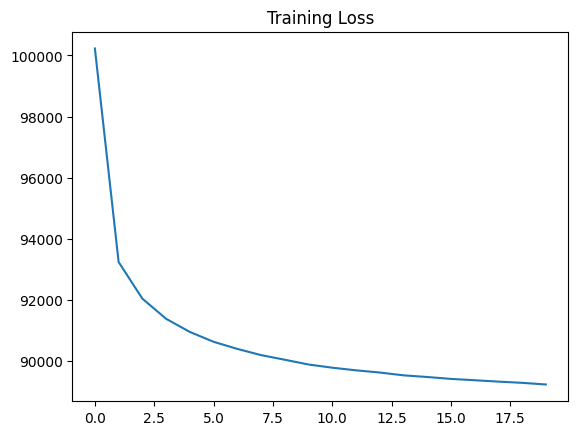

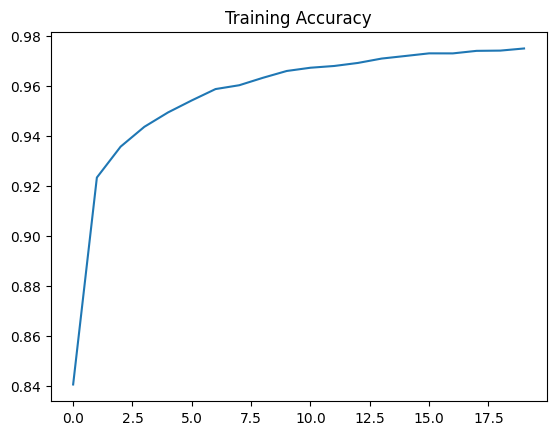

In [5]:
epochs = 20
loss_hist = []
acc_hist = []

for ep in range(epochs):
    total_correct = 0
    total_loss = 0

    model.train()
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()

        # Forward pass (collect spikes over time)
        spk_rec = model(x, num_steps)   # shape: [T, B, C]

        # Compute prediction from spike counts BEFORE calling backward.
        # This avoids using tensors freed by autograd after backward().
        spk_sum = spk_rec.sum(0)       # [B, C]
        _, pred = spk_sum.max(1)

        # Compute loss and backpropagate
        loss = loss_fn(spk_rec, y)
        loss.backward()
        optimizer.step()

        # Accumulate statistics (use .item() so we don't keep graph)
        total_loss += loss.item() * x.size(0)
        total_correct += (pred == y).sum().item()

    acc = total_correct / len(train_ds)
    loss_hist.append(total_loss)
    acc_hist.append(acc)

    print(f"Epoch {ep+1}: Loss={total_loss:.3f}, Acc={acc:.4f}")

# Save the trained model
torch.save(model.state_dict(), "snn_floats_model.pth")

# Plot training curves
plt.plot(loss_hist)
plt.title("Training Loss")
plt.show()

plt.plot(acc_hist)
plt.title("Training Accuracy")
plt.show()

In [6]:
all_preds = []
all_labels = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        spk_rec = model(x, num_steps)
        _, pred = spk_rec.sum(0).max(1)
        all_preds.extend(pred.cpu().numpy())
        all_labels.extend(y.numpy())


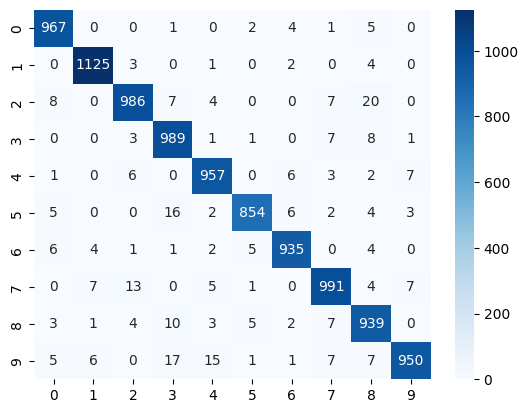

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.98      0.99      0.99      1135
           2       0.97      0.96      0.96      1032
           3       0.95      0.98      0.96      1010
           4       0.97      0.97      0.97       982
           5       0.98      0.96      0.97       892
           6       0.98      0.98      0.98       958
           7       0.97      0.96      0.97      1028
           8       0.94      0.96      0.95       974
           9       0.98      0.94      0.96      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



In [7]:
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.show()


print(classification_report(all_labels, all_preds))


### Fine Tune for Q8.8 format

In [ ]:
# --- Quantization-Aware Fine-Tuning (Q8.8) ---
# This cell implements a simple fake-quant (STE) and wraps the Linear layers
# so weights/activations are rounded to Q8.8 during forward while keeping
# float parameters for gradient updates.

import copy
import torch.nn.functional as F

# Straight-through-rounding (STE) autograd function
class RoundSTE(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, scale):
        # x: float tensor; scale: float scalar

        # scale is a Python scalar or tensor; cast to tensor for consistent dtype/device
        if not torch.is_tensor(scale):
            scale_t = torch.tensor(scale, dtype=x.dtype, device=x.device)
        else:
            scale_t = scale
        return torch.round(x * scale_t) / scale_t

    @staticmethod
    def backward(ctx, grad_output):
        # Straight-through: pass gradient unchanged
        return grad_output, None


def fake_quant(x, scale):
    # convenience wrapper
    return RoundSTE.apply(x, scale)


class QLinear(nn.Module):
    """Wrapper around an nn.Linear which fake-quantizes weights, bias and
    activations to Qm.n during forward using STE."""
    def __init__(self, linear_module: nn.Linear, q_frac_bits: int = 8):
        super().__init__()
        # keep references to original parameter tensors so optimizer updates them
        self.weight = linear_module.weight
        self.bias = linear_module.bias if linear_module.bias is not None else None
        self.in_features = linear_module.in_features
        self.out_features = linear_module.out_features
        self.q_frac_bits = q_frac_bits
        self.scale = float(1 << q_frac_bits)

    def forward(self, input: torch.Tensor) -> torch.Tensor:
        # fake-quantize input activations, weights and bias (STE)
        x_q = fake_quant(input, self.scale)
        w_q = fake_quant(self.weight, self.scale)
        b_q = fake_quant(self.bias, self.scale) if self.bias is not None else None
        return F.linear(x_q, w_q, b_q)


def make_qat_model(float_model: nn.Module, q_frac_bits: int = 8):
    """Create a QAT model where Linear layers are wrapped to fake-quantize
    during forward. This keeps float parameters for training but simulates
    Q8.8 behavior.

    Assumes `float_model` has attributes `fc1` and `fc2` (adapt if names differ).
    """
    qat_model = copy.deepcopy(float_model)

    # Replace fully-connected layers with QLinear wrappers where present
    for name, module in qat_model.named_children():
        if isinstance(module, nn.Linear):
            setattr(qat_model, name, QLinear(module, q_frac_bits=q_frac_bits))
        # if there are nested modules (unlikely here), you could handle recursively

    # If model defines fc1/fc2 under attributes (common pattern) replace them explicitly
    if hasattr(qat_model, "fc1") and isinstance(qat_model.fc1, nn.Linear):
        qat_model.fc1 = QLinear(qat_model.fc1, q_frac_bits=q_frac_bits)
    if hasattr(qat_model, "fc2") and isinstance(qat_model.fc2, nn.Linear):
        qat_model.fc2 = QLinear(qat_model.fc2, q_frac_bits=q_frac_bits)

    return qat_model


# --- Usage: load your floating model, create QAT model and fine-tune ---

q_frac_bits = 8
Q_SCALE = 1 << q_frac_bits

# Load float model
float_model_path = "snn_floats_model.pth"
if not os.path.exists(float_model_path):
    print(f"[WARN] Float model '{float_model_path}' not found in notebook directory.\nPlace it there or modify `float_model_path`.")

# Construct float model instance (must match architecture used in training)
float_model = SNN_FPGAModel(hidden=hidden_neurons, beta=beta)
float_model.load_state_dict(torch.load(float_model_path, map_location="cpu"))
float_model.to(device)
float_model.eval()

# Build QAT model (shares parameters via copy; we want a fresh model with same initial weights)
qat_model = make_qat_model(float_model, q_frac_bits=q_frac_bits)
qat_model.to(device)
qat_model.train()

# Optimizer: low LR for fine-tuning
qat_optimizer = torch.optim.Adam(qat_model.parameters(), lr=2e-5)
qat_epochs = 5  # small number of epochs usually enough for QAT fine-tune
criterion = SF.ce_rate_loss()

print(f"Starting QAT fine-tuning: q_frac_bits={q_frac_bits}, scale={Q_SCALE}, epochs={qat_epochs}")

for ep in range(qat_epochs):
    running_loss = 0.0
    running_correct = 0
    n_samples = 0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        qat_optimizer.zero_grad()

        # Forward through the QAT model (it will fake-quantize weights+activations)
        spk_rec = qat_model(xb, num_steps)

        # compute loss and backward
        loss = criterion(spk_rec, yb)
        loss.backward()
        qat_optimizer.step()

        # stats
        running_loss += loss.item() * xb.size(0)
        _, pred = spk_rec.sum(0).max(1)
        running_correct += (pred == yb).sum().item()
        n_samples += xb.size(0)

    epoch_loss = running_loss / n_samples
    epoch_acc = running_correct / n_samples
    print(f"QAT Epoch {ep+1}/{qat_epochs}: Loss={epoch_loss:.4f}, Acc={epoch_acc:.4f}")

# Save the fine-tuned float parameters (still stored as float but tuned for Q8.8 behavior)
qat_state_path = "snn_qat_model.pth"
torch.save(qat_model.state_dict(), qat_state_path)
print(f"Saved fine-tuned QAT model state to {qat_state_path}")

### Weight Export for VHDL

Generates a VHDL package (weights_pkg.vhd) from numpy weight/bias arrays.

Supports configurable fixed-point quantization Qm.n by specifying fractional bits (q_frac_bits).
Default uses Q8.8 (q_frac_bits = 8) -> scale = 256.

Expected array shapes:
 - W_input_hidden:  (N_HIDDEN, N_INPUTS)
 - B_input_hidden:  (N_HIDDEN,)
 - W_hidden_output: (N_OUTPUT, N_HIDDEN)
 - B_hidden_output: (N_OUTPUT,)

If you have only one hidden layer, pass W_hidden_output, B_hidden_output as normal.
If you have two hidden layers you can extended this script similarly.

In [ ]:
# Helper: convert numpy int array to vhdl row string
def _vhdl_row_list(arr_row):
    # return string like "0 => 12, 1 => -3, 2 => 0"
    elems = []
    for j, v in enumerate(arr_row):
        elems.append(f"{j} => {int(v)}")
    return ", ".join(elems)


def write_weights_pkg_vhdl(
    filename: str,
    W_input_hidden: np.ndarray,
    B_input_hidden: np.ndarray,
    W_hidden_output: np.ndarray,
    B_hidden_output: np.ndarray,
    q_frac_bits: int = 8,
    lif_beta: float = 0.9,        # leaky beta, in float (0..1)
    threshold: float = 1.0,       # threshold in same scale as activations (float)
    vhdl_pkg_name: str = "weights_pkg",
    comment: str = ""
):
    """
    Write a VHDL package file containing quantized weights & biases and helper constants.

    - filename: output file path (e.g. "weights_pkg.vhd")
    - q_frac_bits: number of fractional bits (n in Qm.n). Q8.8 => q_frac_bits = 8
    - lif_beta, threshold will be quantized with same Q format
    """
    # Validate shapes
    W_input_hidden = np.asarray(W_input_hidden)
    B_input_hidden = np.asarray(B_input_hidden)
    W_hidden_output = np.asarray(W_hidden_output)
    B_hidden_output = np.asarray(B_hidden_output)

    assert W_input_hidden.ndim == 2, "W_input_hidden must be 2D (N_HIDDEN, N_INPUTS)"
    assert W_hidden_output.ndim == 2, "W_hidden_output must be 2D (N_OUTPUT, N_HIDDEN)"
    assert B_input_hidden.ndim == 1
    assert B_hidden_output.ndim == 1

    N_HIDDEN, N_INPUTS = W_input_hidden.shape
    N_OUTPUT, N_HIDDEN2 = W_hidden_output.shape
    assert N_HIDDEN == N_HIDDEN2, "Hidden size mismatch between W_input_hidden and W_hidden_output"
    assert B_input_hidden.size == N_HIDDEN
    assert B_hidden_output.size == N_OUTPUT

    # Quantization parameters
    Q_BITS = q_frac_bits
    Q_SCALE = 1 << Q_BITS
    Q_NAME = f"Q{(16-Q_BITS)}.{Q_BITS}"  # rough label (not exact m bits)
    INT_MIN, INT_MAX = -32768, 32767  # matches int16 subtype in types_pkg

    # Quantize arrays (round -> int)
    def q(arr):
        a = np.rint(np.asarray(arr, dtype=np.float64) * Q_SCALE).astype(np.int64)
        # clip to int16 range
        a = np.clip(a, INT_MIN, INT_MAX)
        return a.astype(np.int32)

    W1_q = q(W_input_hidden)
    B1_q = q(B_input_hidden)
    W3_q = q(W_hidden_output)
    B3_q = q(B_hidden_output)

    lif_beta_q = int(round(lif_beta * Q_SCALE))
    threshold_q = int(round(threshold * Q_SCALE))

    # Write VHDL
    with open(filename, "w") as f:
        f.write(f"-- Auto-generated VHDL weights package\n")
        f.write(f"-- Source: snn_test.ipynb\n")
        f.write(f"-- Format: fixed-point {Q_NAME} (frac bits={Q_BITS}, scale={Q_SCALE})\n")
        if comment:
            f.write(f"-- {comment}\n")
        f.write("\n")
        f.write("library IEEE;\n")
        f.write("use IEEE.STD_LOGIC_1164.ALL;\n")
        f.write("use IEEE.NUMERIC_STD.ALL;\n")
        f.write("use work.types_pkg.all;\n\n")
        f.write(f"package {vhdl_pkg_name} is\n\n")

        # sizes and Q constants
        f.write(f"  -- Network sizes\n")
        f.write(f"  constant N_INPUTS  : integer := {N_INPUTS};\n")
        f.write(f"  constant N_HIDDEN  : integer := {N_HIDDEN};\n")
        f.write(f"  constant N_OUTPUT  : integer := {N_OUTPUT};\n\n")

        f.write(f"  -- Fixed-point quantization (Q format)\n")
        f.write(f"  -- fractional bits (n): number of bits for fraction\n")
        f.write(f"  constant Q_FRAC_BITS : integer := {Q_BITS};\n")
        f.write(f"  constant Q_SCALE     : integer := {Q_SCALE};  -- scaling factor (2^Q_FRAC_BITS)\n\n")

        f.write(f"  -- LIF / neuron parameters (quantized in same Q format)\n")
        f.write(f"  constant LIF_BETA_Q  : integer := {lif_beta_q};  -- beta * Q_SCALE\n")
        f.write(f"  constant THRESHOLD_Q : integer := {threshold_q};  -- threshold * Q_SCALE\n\n")

        # Declare constants using integer_matrix/integer_vector types from types_pkg
        f.write("  -- Weight matrices (quantized integers, clipped to int16 range)\n")
        f.write(f"  constant W_INPUT_HIDDEN : integer_matrix(0 to {N_HIDDEN-1}, 0 to {N_INPUTS-1}) := (\n")
        for n in range(N_HIDDEN):
            row = _vhdl_row_list(W1_q[n])
            sep = "," if n < N_HIDDEN-1 else ""
            f.write(f"    {n} => ({row}){sep}\n")
        f.write("  );\n\n")

        f.write(f"  constant B_INPUT_HIDDEN : integer_vector(0 to {N_HIDDEN-1}) := (")
        f.write(", ".join(str(int(x)) for x in B1_q))
        f.write(");\n\n")

        f.write(f"  constant W_HIDDEN_OUTPUT : integer_matrix(0 to {N_OUTPUT-1}, 0 to {N_HIDDEN-1}) := (\n")
        for n in range(N_OUTPUT):
            row = _vhdl_row_list(W3_q[n])
            sep = "," if n < N_OUTPUT-1 else ""
            f.write(f"    {n} => ({row}){sep}\n")
        f.write("  );\n\n")

        f.write(f"  constant B_HIDDEN_OUTPUT : integer_vector(0 to {N_OUTPUT-1}) := (")
        f.write(", ".join(str(int(x)) for x in B3_q))
        f.write(");\n\n")

        f.write(f"  -- Helpful human-readable info (floating point equivalents)\n")
        f.write(f"  -- NOTE: stored integers represent value * Q_SCALE\n")
        f.write(f"  -- Example: real_weight = stored_int / Q_SCALE\n\n")

        f.write("end package " + vhdl_pkg_name + ";\n")

    print(f"[OK] Wrote VHDL package to {os.path.abspath(filename)}")
    print(f"  format: Q frac bits = {Q_BITS} (scale={Q_SCALE}), lif_beta_q={lif_beta_q}, threshold_q={threshold_q}")
    print(f"  shapes: W1 {W1_q.shape}, B1 {B1_q.shape}, W3 {W3_q.shape}, B3 {B3_q.shape}")

In [ ]:

# --- Export quantized integer weights for VHDL ---
# Use existing write_weights_pkg_vhdl() helper: pass floating arrays; it will quantize using q_frac_bits=8
try:
    # Extract numpy arrays in expected shapes: W_input_hidden (N_HIDDEN, N_INPUTS), B_input_hidden (N_HIDDEN,),
    # W_hidden_output (N_OUTPUT, N_HIDDEN), B_hidden_output (N_OUTPUT,)
    # Our model uses fc1 (256 -> hidden) and fc2 (hidden -> 10)
    W_input_hidden = qat_model.fc1.weight.detach().cpu().numpy()
    B_input_hidden = qat_model.fc1.bias.detach().cpu().numpy()
    W_hidden_output = qat_model.fc2.weight.detach().cpu().numpy()
    B_hidden_output = qat_model.fc2.bias.detach().cpu().numpy()

    # Write package (this function quantizes inside to Q8.8 when you pass q_frac_bits=8)
    write_weights_pkg_vhdl(
        filename="weights_pkg.vhd",
        W_input_hidden=W_input_hidden,
        B_input_hidden=B_input_hidden,
        W_hidden_output=W_hidden_output,
        B_hidden_output=B_hidden_output,
        q_frac_bits=q_frac_bits,
        lif_beta=beta,
        threshold=1.0,  # keep threshold=1.0 (or compute/adjust to what you used in model)
        comment="QAT-fine-tuned model exported to Q8.8"
    )

except Exception as e:
    print("[ERROR] Failed to export quantized weights for VHDL:", e)

print("QAT fine-tuning + export complete.")

[OK] Wrote VHDL package to e:\Programmes\SNN-FPGA\Python scripts\weights_pkg_q8_8.vhd
  format: Q frac bits = 8 (scale=256), lif_beta_q=230, threshold_q=256
  shapes: W1 (64, 256), B1 (64,), W3 (10, 64), B3 (10,)
QAT fine-tuning + export complete.


## Model simulation (using quantized(Q8.8) model)

### Load PNG & preprocess (MNIST style)

In [54]:
from PIL import Image

device = 'cpu'


def load_mnist_png(path):
    img = Image.open(path).convert("L")   # grayscale
    img = img.resize((16, 16))            # your FPGA uses 256 inputs
    arr = np.array(img).astype(np.float32) / 255.0

    arr = torch.tensor(arr).flatten()     # shape: (256,)
    return arr

sample = load_mnist_png("sample MNIST data\\6.png").to(device)
print("Input shape:", sample.shape)   # torch.Size([256])

Input shape: torch.Size([256])


### Forward-pass with full internal state capture

In [55]:
# ----------------------------------------------------------
# Load QAT model (float weights, tuned for int)
# ----------------------------------------------------------
qat_model = SNN_FPGAModel(hidden=hidden_neurons, beta=beta)
qat_model.load_state_dict(torch.load("snn_qat_model.pth", map_location="cpu"))
qat_model.eval()

# Extract float weights/biases
W1_f = qat_model.fc1.weight.detach().cpu().numpy()
b1_f = qat_model.fc1.bias.detach().cpu().numpy()
W2_f = qat_model.fc2.weight.detach().cpu().numpy()
b2_f = qat_model.fc2.bias.detach().cpu().numpy()

# ----------------------------------------------------------
# Convert to Q8.8 integers (exactly like FPGA)
# ----------------------------------------------------------
Q_BITS = 8
Q_SCALE = 1 << Q_BITS

def quantize_q8_8(arr):
    q = np.rint(arr * Q_SCALE).astype(np.int32)
    return np.clip(q, -32768, 32767)

# Quantized weights
W1_q = quantize_q8_8(W1_f)     # shape: [hidden, 256]
b1_q = quantize_q8_8(b1_f)     # shape: [hidden]
W2_q = quantize_q8_8(W2_f)     # shape: [10, hidden]
b2_q = quantize_q8_8(b2_f)

beta_q = int(round(beta * Q_SCALE))
th_q   = int(round(1.0 * Q_SCALE))

# ----------------------------------------------------------
# Quantize input image
# ----------------------------------------------------------
x_f = sample.numpy()
x_q = quantize_q8_8(x_f)    # integer input to FPGA

# ==========================================================
#  Forward Pass in Fixed Point (Q8.8 math)
# ==========================================================

def dense_q8_8(x_q, W_q, b_q):
    """
    Performs: z = x·W^T + b  (all integer math)
    x_q shape: [256]
    W_q shape: [N, 256]
    returns z_q (integer)
    """
    # Multiply-accumulate → stays in int32
    z = (W_q @ x_q) // Q_SCALE + b_q  # scale correction like FPGA
    return z.astype(np.int32)

# ----------------------------------------------------------
# LIF hidden layer (1 time step for debugging)
# ----------------------------------------------------------
def lif_step_q8_8(z_q, v_prev_q, beta_q, th_q):
    """
    z_q, v_prev_q, beta_q, th_q are integers in Q8.8 scale
    """
    # v = beta*v_prev + z
    v_q = (beta_q * v_prev_q) // Q_SCALE + z_q

    # spike?
    spike = (v_q > th_q).astype(np.int32)

    # reset after spike
    v_q = np.where(spike == 1, v_q - th_q, v_q)

    return v_q, spike

# ===============================
#  Run Hidden Layer
# ===============================

v1_prev = np.zeros_like(b1_q)

# Dense layer → Q8.8 membrane update
z1_q = dense_q8_8(x_q, W1_q, b1_q)

# LIF neuron update
v1_q, s1_q = lif_step_q8_8(z1_q, v1_prev, beta_q, th_q)

# ===============================
#  Output layer dense
# ===============================
z2_q = dense_q8_8(v1_q, W2_q, b2_q)

# Output logits (integer, Q8.8)
logits_q8_8 = z2_q

print("\n--- DEBUG OUTPUT ---")
print("Input Q8.8:", x_q)
print("Hidden weighted sum z1:", z1_q)
print("Hidden membrane v1:", v1_q)
print("Hidden spikes s1:", s1_q)
print("Output logits (Q8.8):", logits_q8_8)
print("Predicted class:", np.argmax(logits_q8_8))



--- DEBUG OUTPUT ---
Input Q8.8: [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   5 140  79   0   0   0   0   0   0   0   0   0   0   0
   0   0  80 226  37   0   0   0   0   0   0   0   0   0   0   0   0   3
 196 164   0   0   0   0   0   0   0   0   0   0   0   0   0  28 230 112
   0   0   0   0   0   0   0   0   0   0   0   0   0 101 234  23   0   0
   0   0   0   0   0   0   0   0   0   0   0 137 213   0   0  19  61  67
   8   0   0   0   0   0   0   0   0 152 163   0  80 218 253 249 155   9
   0   0   0   0   0   0   0 192 140 112 237 155  66  54 213  33   0   0
   0   0   0   0   0 191 214 239  89   0   0  21 212  35   0   0   0   0
   0   0   0 138 256 163   0   0  69 187 139   9   0   0   0   0   0   0
   0  28 204 227 167 175 234 118   0   0   0   0   0   0   0   0   0   0
  24 123 159 139  51   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0 

## generate a testing data: 16x16 image

In [ ]:
# --- Python Helper to Generate VHDL Testbench Data ---

# Format as VHDL Array String
vhdl_array_str = ", ".join(str(x) for x in x_q)

print("--- COPY THIS INTO tb_snn_core.vhd (signal test_input) ---")
print(vhdl_array_str)

--- COPY THIS INTO tb_snn_core.vhd (signal test_input) ---
0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 5, 140, 79, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 80, 226, 37, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 196, 164, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 28, 230, 112, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 101, 234, 23, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 137, 213, 0, 0, 19, 61, 67, 8, 0, 0, 0, 0, 0, 0, 0, 0, 152, 163, 0, 80, 218, 253, 249, 155, 9, 0, 0, 0, 0, 0, 0, 0, 192, 140, 112, 237, 155, 66, 54, 213, 33, 0, 0, 0, 0, 0, 0, 0, 191, 214, 239, 89, 0, 0, 21, 212, 35, 0, 0, 0, 0, 0, 0, 0, 138, 256, 163, 0, 0, 69, 187, 139, 9, 0, 0, 0, 0, 0, 0, 0, 28, 204, 227, 167, 175, 234, 118, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 24, 123, 159, 139, 51, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0
